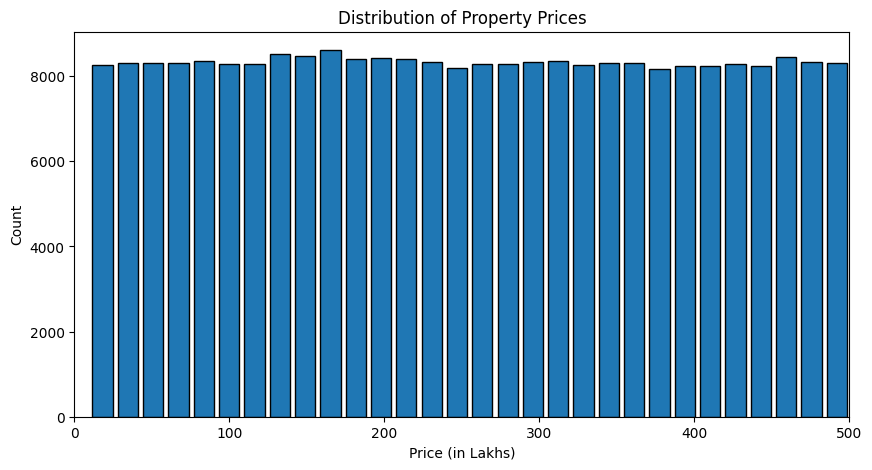

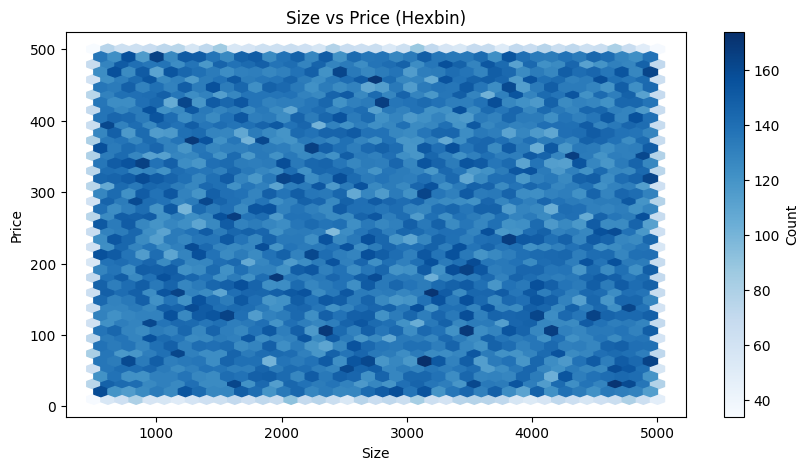

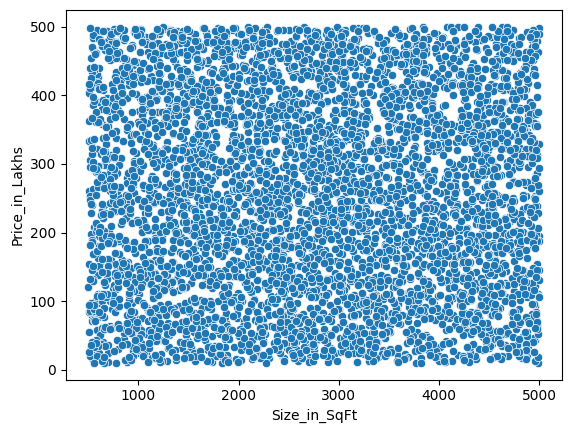

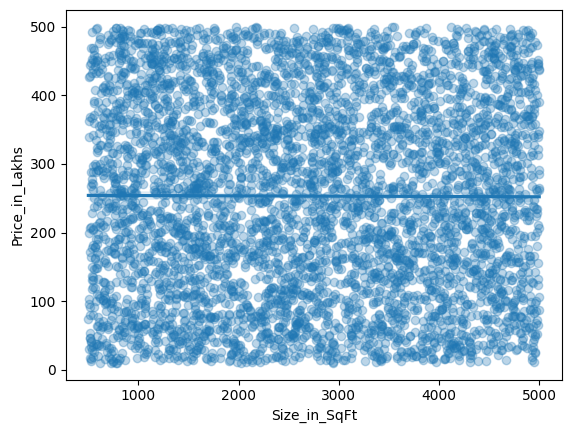

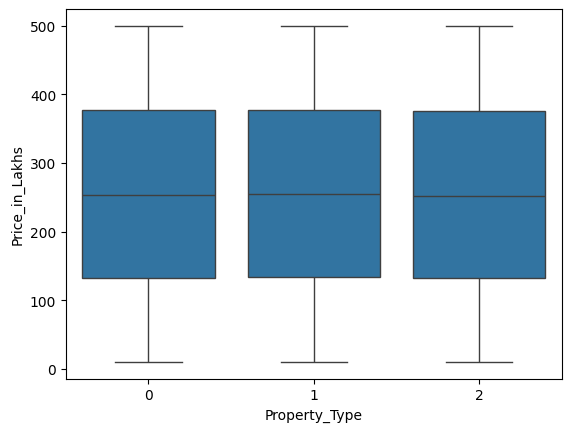

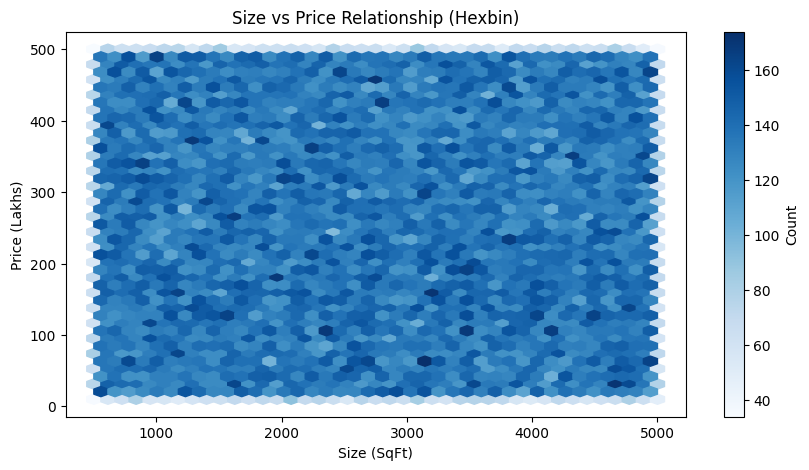

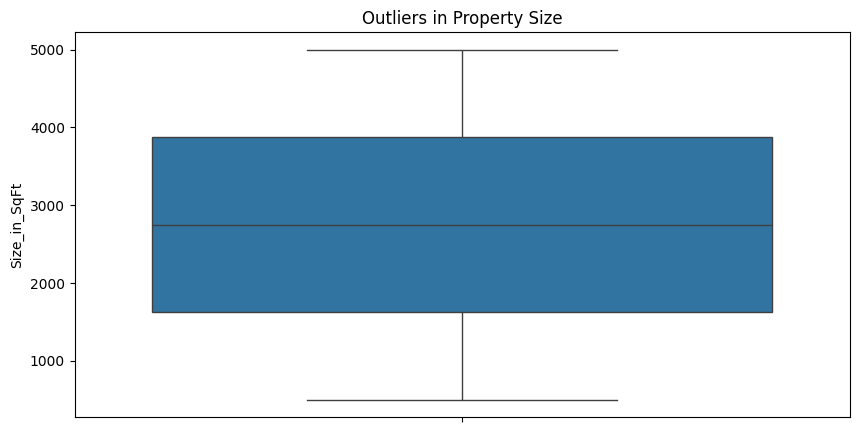

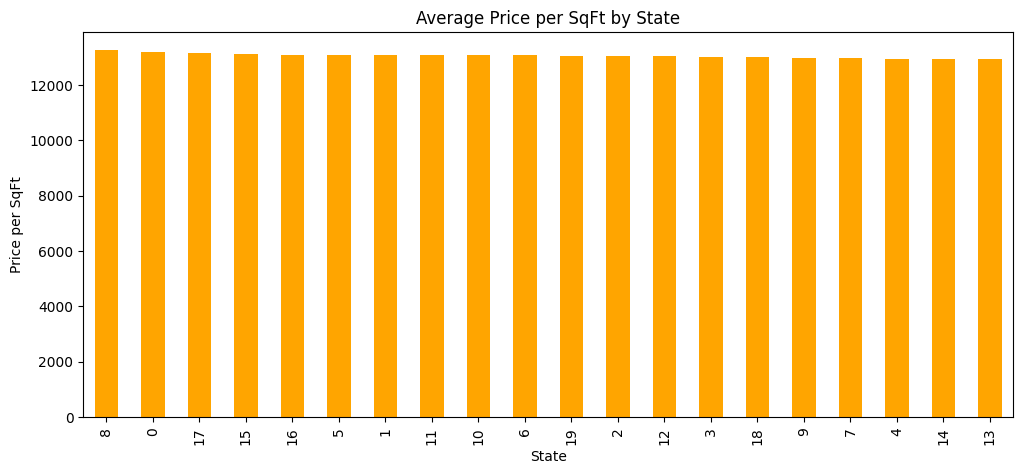

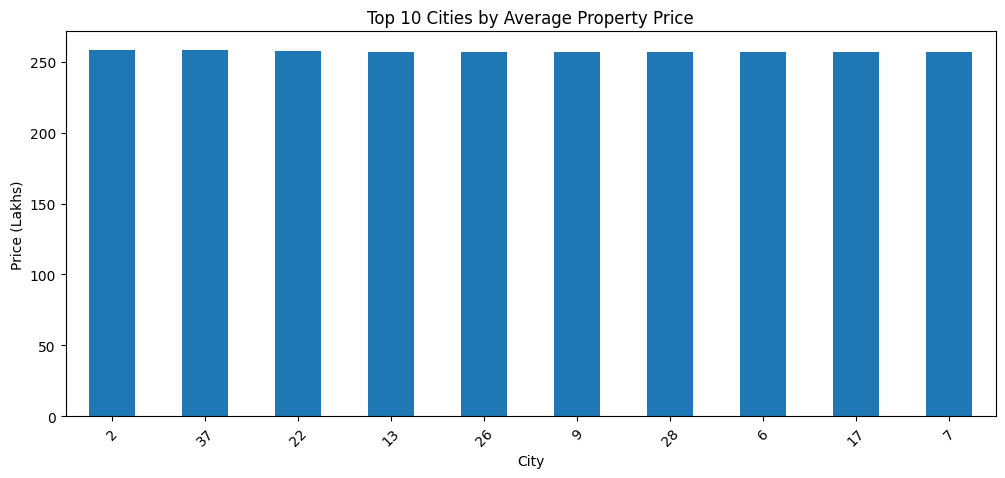

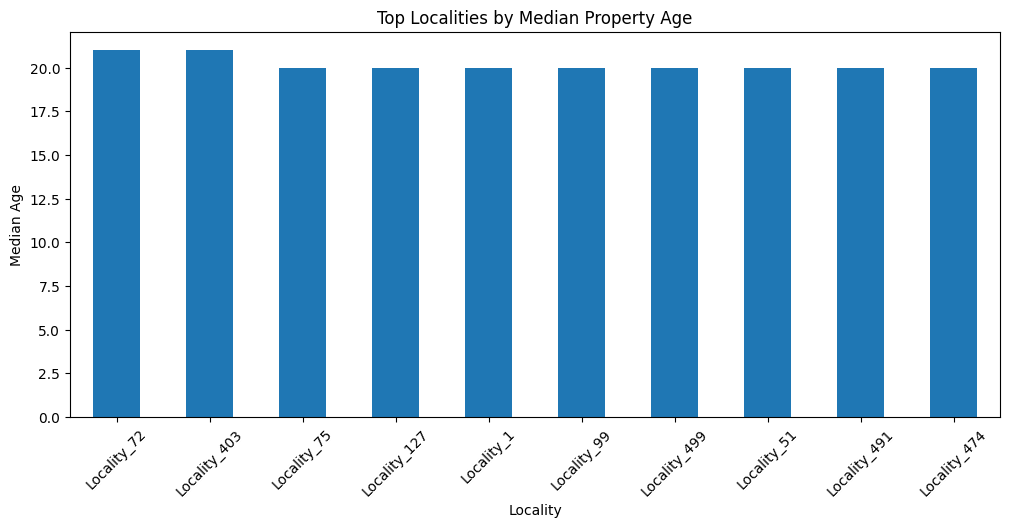

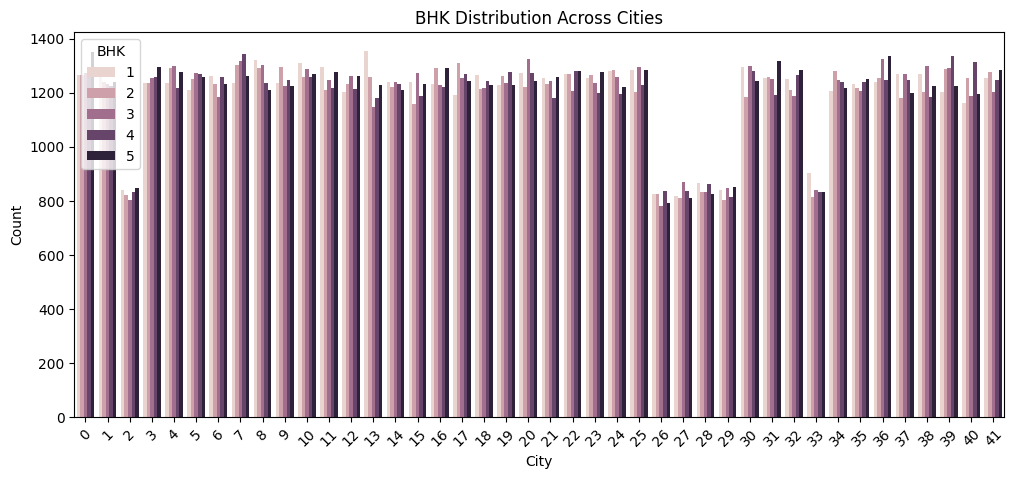

C:\Users\vashu\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


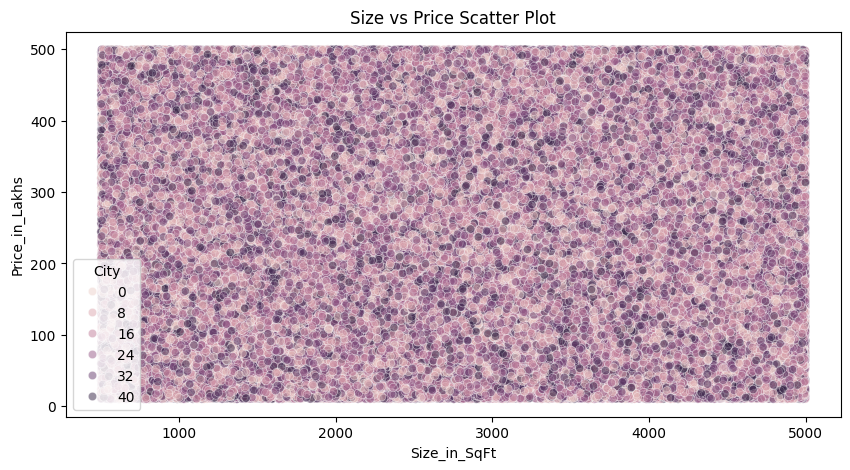

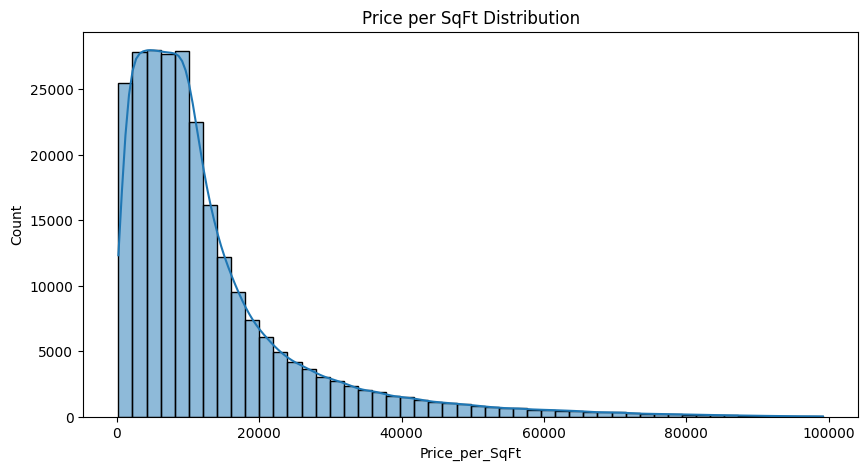

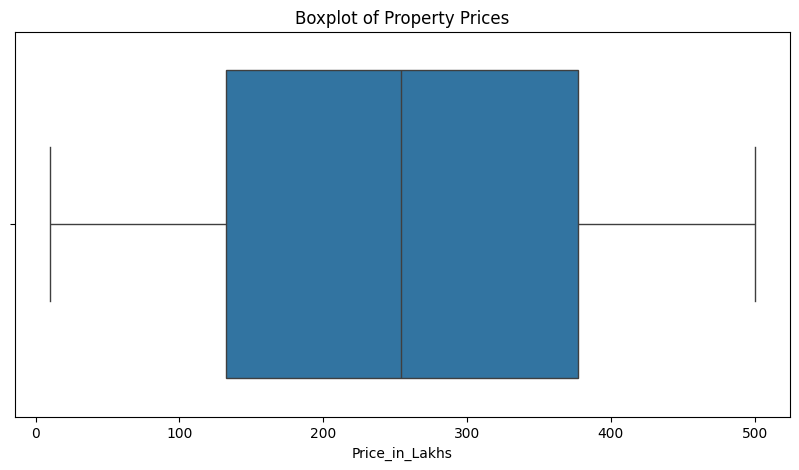

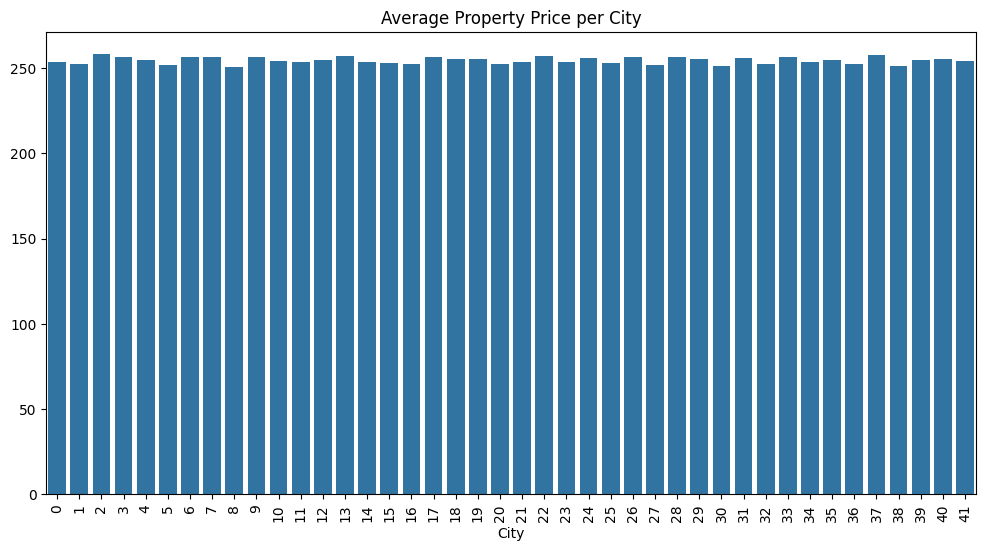

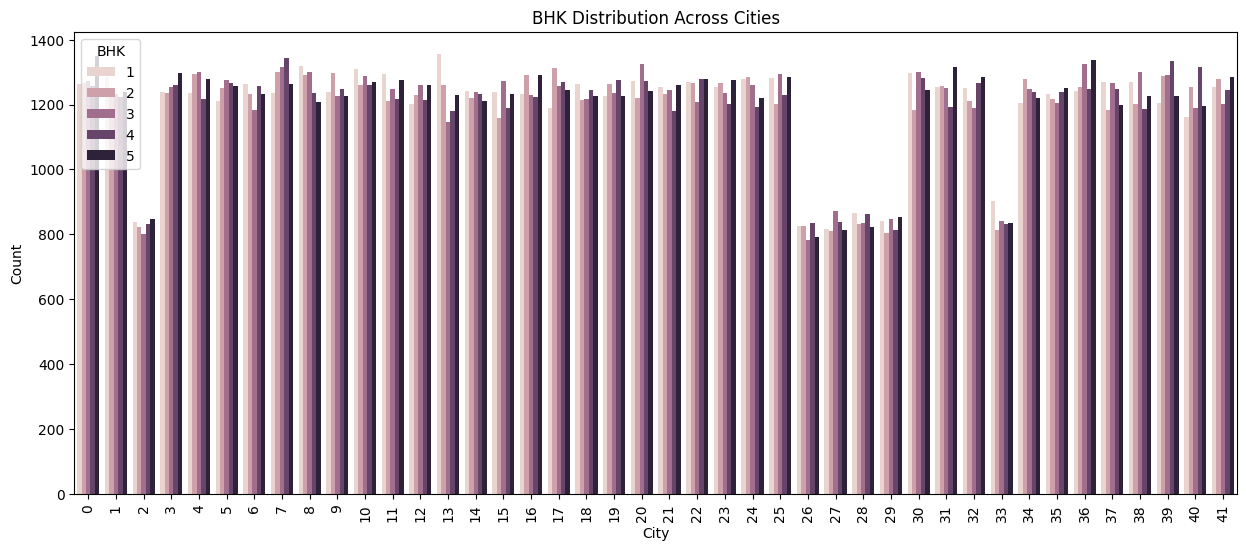

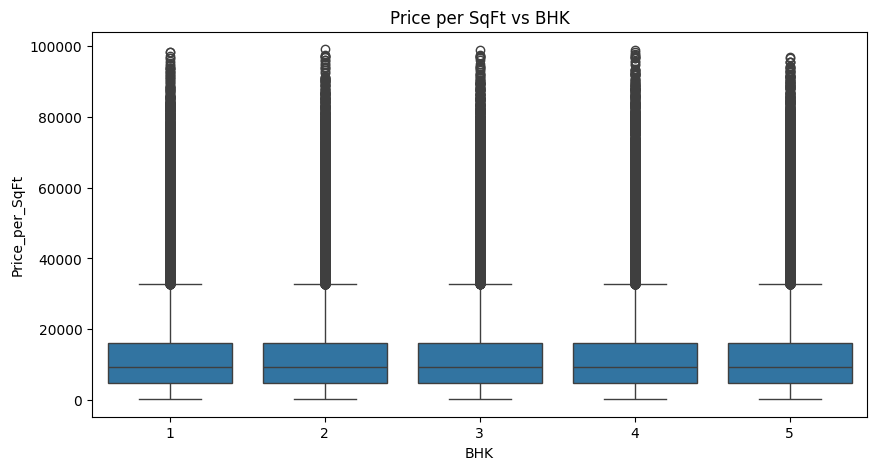

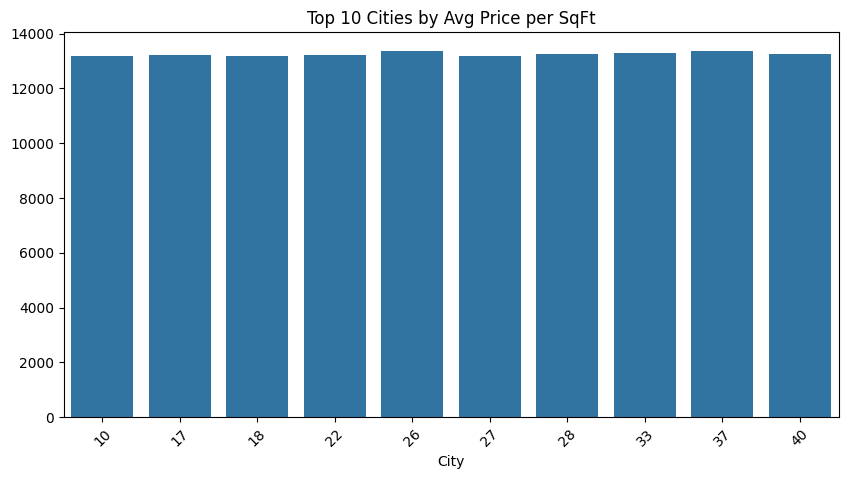

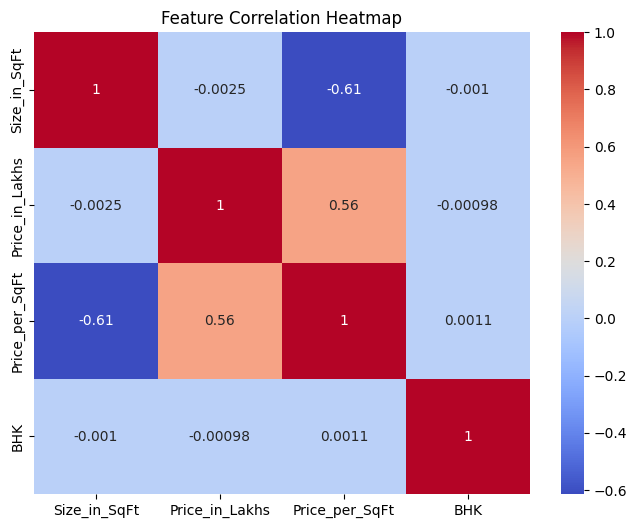

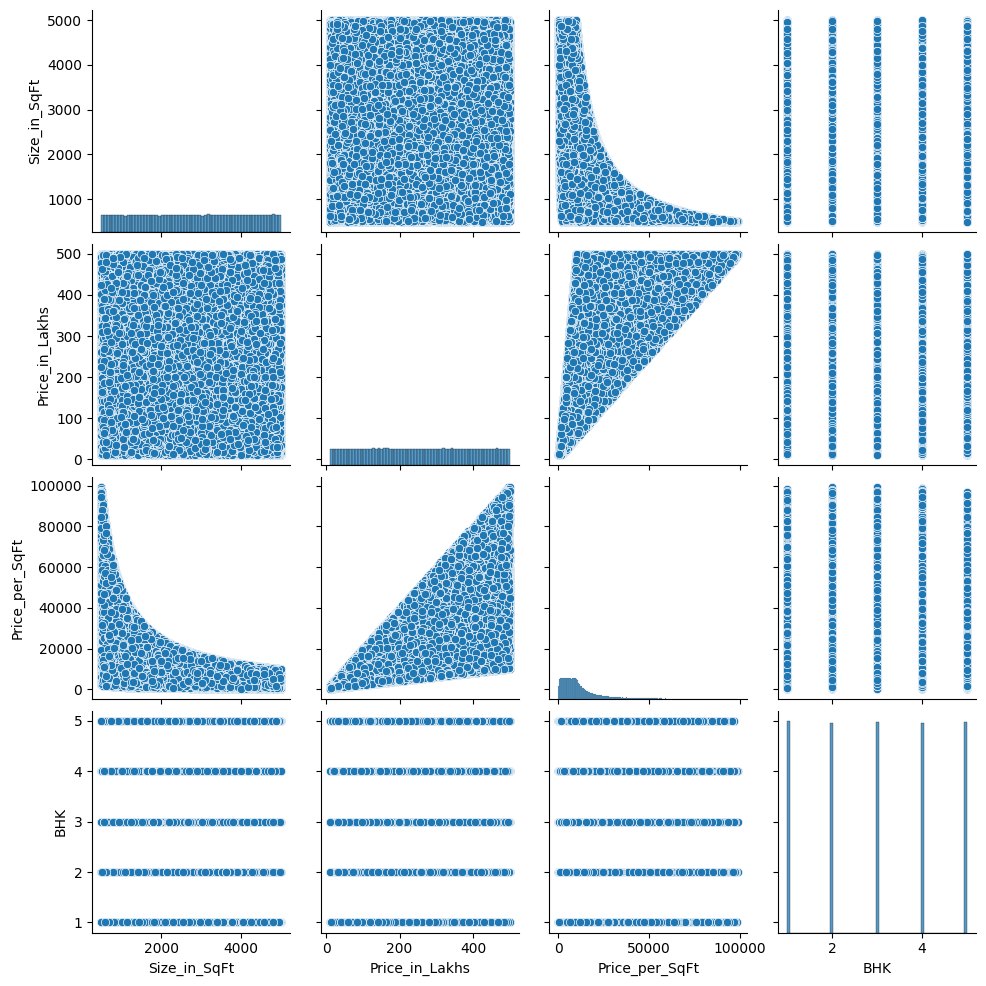

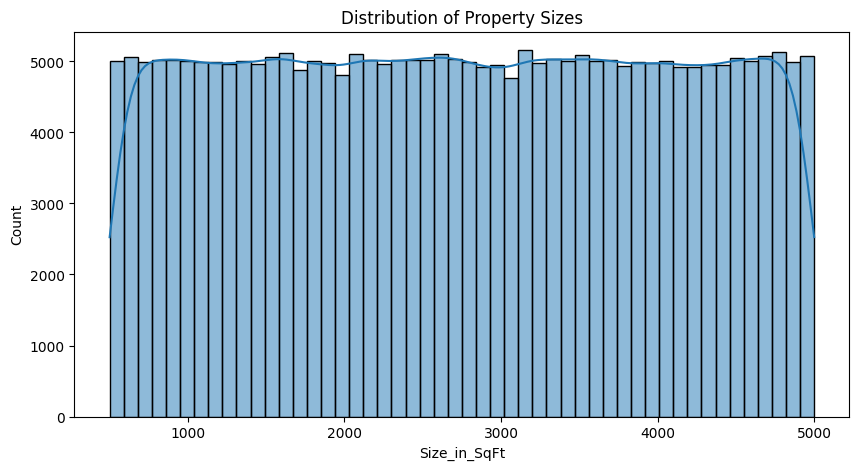

DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  int64  
 2   City                            250000 non-null  int64  
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  int64  
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  int64  
 11  Floor_No                        250000 non-null  int64  
 12  Total

{0: 125000, 1: 125000}

In [ ]:
import pandas as pd
import numpy as np

# 🔹 STEP 1: Load Data
df = pd.read_csv(r"C:\Users\vashu\cleaned_data_final.csv")
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
plt.hist(df["Price_in_Lakhs"], bins=30, rwidth =0.8,edgecolor="black")
plt.title("Distribution of Property Prices")
plt.xlabel("Price (in Lakhs)")
plt.ylabel("Count")
plt.xlim(0,500)
plt.show()

plt.figure(figsize=(10,5))

plt.hexbin(
    df["Size_in_SqFt"],
    df["Price_in_Lakhs"],
    gridsize=40,
    cmap='Blues'
)

plt.colorbar(label='Count')
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Size vs Price (Hexbin)")

plt.show()

sample_df = df.sample(5000)

sns.scatterplot(
    x="Size_in_SqFt",
    y="Price_in_Lakhs",
    data=sample_df
)

plt.show()

sample_df = df.sample(5000)

sns.regplot(
    x="Size_in_SqFt",
    y="Price_in_Lakhs",
    data=sample_df,
    scatter_kws={'alpha':0.3}
)

plt.show()

sns.boxplot(x="Property_Type", y="Price_in_Lakhs", data=df)
plt.show()

plt.figure(figsize=(10,5))

plt.hexbin(
    df["Size_in_SqFt"],
    df["Price_in_Lakhs"],
    gridsize=40,
    cmap='Blues'
)

plt.colorbar(label='Count')

plt.xlabel("Size (SqFt)")
plt.ylabel("Price (Lakhs)")
plt.title("Size vs Price Relationship (Hexbin)")

plt.show()

plt.figure(figsize=(10,5))

sns.boxplot(y=df["Size_in_SqFt"])

plt.title("Outliers in Property Size")

plt.show()

plt.figure(figsize=(12,5))

avg_price_state = df.groupby("State")["Price_per_SqFt"].mean().sort_values(ascending=False)

avg_price_state.plot(kind="bar")

plt.title("Average Price per SqFt by State")
plt.xlabel("State")
plt.ylabel("Price per SqFt")

plt.xticks(rotation=45)
avg_price_state.plot(kind="bar", color = "orange")

plt.show()

plt.figure(figsize=(12,5))

avg_price_city = df.groupby("City")["Price_in_Lakhs"].mean().sort_values(ascending=False)

avg_price_city.head(10).plot(kind="bar")

plt.title("Top 10 Cities by Average Property Price")
plt.xlabel("City")
plt.ylabel("Price (Lakhs)")

plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(12,5))

median_age = df.groupby("Locality")["Age_of_Property"].median().sort_values(ascending=False)

median_age.head(10).plot(kind="bar")

plt.title("Top Localities by Median Property Age")
plt.xlabel("Locality")
plt.ylabel("Median Age")

plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(12,5))

sns.countplot(x="City", hue="BHK", data=df)
plt.title("BHK Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x='Size_in_SqFt', y='Price_in_Lakhs', data=df, hue='City', alpha=0.5)
plt.title('Size vs Price Scatter Plot')
plt.show()

# =========================
# 12️⃣ Histogram Price per SqFt
# =========================
plt.figure(figsize=(10,5))
sns.histplot(df['Price_per_SqFt'], bins=50, kde=True)
plt.title('Price per SqFt Distribution')
plt.show()

# =========================
# 13️⃣ Boxplot to Show Outliers in Price
# =========================
plt.figure(figsize=(10,5))
sns.boxplot(x='Price_in_Lakhs', data=df)
plt.title('Boxplot of Property Prices')
plt.show()

# =========================
# 14️⃣ Average Price per City
# =========================
avg_price = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.xticks(rotation=90)
plt.title('Average Property Price per City')
plt.show()

# =========================
# 15️⃣ BHK Distribution per City
# =========================
bhk_city = df.groupby(['City','BHK']).size().reset_index(name='Count')
plt.figure(figsize=(15,6))
sns.barplot(x='City', y='Count', hue='BHK', data=bhk_city)
plt.xticks(rotation=90)
plt.title('BHK Distribution Across Cities')
plt.show()

# =========================
# 16️⃣ Price per SqFt vs BHK
# =========================
plt.figure(figsize=(10,5))
sns.boxplot(x='BHK', y='Price_per_SqFt', data=df)
plt.title('Price per SqFt vs BHK')
plt.show()

# =========================
# 17️⃣ Top 10 Cities by Average Price per SqFt
# =========================
top_cities = df.groupby('City')['Price_per_SqFt'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title('Top 10 Cities by Avg Price per SqFt')
plt.xticks(rotation=45)
plt.show()

# =========================
# 18️⃣ Correlation Heatmap
# =========================
plt.figure(figsize=(8,6))
sns.heatmap(df[['Size_in_SqFt','Price_in_Lakhs','Price_per_SqFt','BHK']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# =========================
# 19️⃣ Pairplot for Numeric Features
# =========================
sns.pairplot(df[['Size_in_SqFt','Price_in_Lakhs','Price_per_SqFt','BHK']])
plt.show()

# =========================
# 20️⃣ Distribution of Sizes
# =========================
plt.figure(figsize=(10,5))
sns.histplot(df['Size_in_SqFt'], bins=50, kde=True)
plt.title('Distribution of Property Sizes')
plt.show()


# 🔹 STEP 2: Check Data
print("DATA INFO:")
print(df.info())

print("\nMISSING VALUES:")
print(df.isnull().sum())

# 🔹 STEP 3: Create Price_per_SqFt (important)
df["Price_per_SqFt"] = (df["Price_in_Lakhs"] * 100000) / df["Size_in_SqFt"]

# 🔹 STEP 4: Create Good Investment column
df["Good_Investment"] = (
    (df["Price_per_SqFt"] < df["Price_per_SqFt"].median()) |
    (df["Amenities"] == "High") |
    (df["Public_Transport_Accessibility"] == "High")
).astype(int)

df["Good_Investment"].value_counts()

# 🔹 STEP 6: Save cleaned data
df.to_csv("cleaned_data.csv", index=False)

# 🔹 STEP 7: Preview
df.head(20)
df["Good_Investment"].value_counts().to_dict()